# 04_03 · Evaluación — Dataset CNC Industrial (KIT Karlsruhe)

**Objetivo**: evaluación formal del mejor modelo sobre el dataset KIT y
análisis de su conexión con el resto del proyecto (SPARK, AI4I).

### Por qué evaluar aquí y no en el notebook de modelos
El notebook de modelos explora y compara. Este notebook consolida:
- El mejor modelo seleccionado con un análisis de error detallado
- El impacto económico estimado
- La validación de la hipótesis de conexión SPARK ↔ KIT ↔ AI4I

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (f1_score, recall_score, precision_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              classification_report)

import sys; sys.path.insert(0, '../../src')
from paths import PROCESSED as PROC_DIR
from kit import FAULT_NAMES, FAULT_COLORS

df = pd.read_csv(os.path.join(PROC_DIR, 'industrial_features_v2.csv'))
feat_cols = [c for c in df.columns
             if c not in ('trial','fault_type','fault_name','anomaly','n_samples')]

# Sin escalar: RF e Isolation Forest son modelos de árbol, insensibles a la
# escala. Escalar con el dataset completo antes del LOO sería leakage.
X = df[feat_cols].values
y = df['anomaly'].values
print(f'{len(df)} experimentos cargados ({y.sum()} anomalias)')
print(f'Por tipo: { {FAULT_NAMES[k]: int((df["fault_type"]==k).sum()) for k in sorted(FAULT_NAMES)} }')

33 experimentos cargados (15 anomalias)
Por tipo: {'Normal': 18, 'Tool Wear': 5, 'Chatter': 1, 'Process Anomaly': 5, 'Workpiece Defect': 4}


## 1. Modelo seleccionado — Random Forest (LOO-CV)

Random Forest con `class_weight='balanced'` es el modelo con mejor AUC
en la evaluación LOO-CV del notebook 03_03. Lo reentrenamos aquí
con el análisis de error experimento a experimento.

In [2]:
loo = LeaveOneOut()
rf  = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                              random_state=42, n_jobs=-1)

yp  = cross_val_predict(rf, X, y, cv=loo)
ypr = cross_val_predict(rf, X, y, cv=loo, method='predict_proba')[:,1]

print('=== RANDOM FOREST — LOO-CV ===')
print(classification_report(y, yp, target_names=['Normal','Anomalía']))
print(f'ROC-AUC: {roc_auc_score(y, ypr):.3f}')

# Detalle por experimento
print(f'\n{"Trial":<20} {"Tipo":<20} {"Real":>5} {"Pred":>5} {"Prob":>6}')
print('─'*58)
for i, (_, row) in enumerate(df.iterrows()):
    ok = '✓' if yp[i]==y[i] else '✗'
    print(f'{row["trial"]:<20} {row["fault_name"]:<20} '
          f'{y[i]:>5} {yp[i]:>5} {ypr[i]:>6.3f} {ok}')

=== RANDOM FOREST — LOO-CV ===
              precision    recall  f1-score   support

      Normal       0.71      0.67      0.69        18
    Anomalía       0.62      0.67      0.65        15

    accuracy                           0.67        33
   macro avg       0.67      0.67      0.67        33
weighted avg       0.67      0.67      0.67        33

ROC-AUC: 0.744

Trial                Tipo                  Real  Pred   Prob
──────────────────────────────────────────────────────────
IM-01F               Normal                   0     1  0.708 ✗
IM-01F-A01           Process Anomaly          1     0  0.240 ✗
IM-01R               Normal                   0     1  0.940 ✗
IM-01R-A01           Tool Wear                1     1  0.848 ✓
IM-01R-A02           Tool Wear                1     1  0.914 ✓
IM-01R-A03           Tool Wear                1     1  0.596 ✓
IM-01R-A04           Tool Wear                1     1  0.820 ✓
IM-01R-A05           Tool Wear                1     1  0.782 ✓
IM

## 2. Comparativa supervisado vs. no supervisado

Isolation Forest entrenado solo en experimentos normales,
para simular el escenario real de despliegue (no se conocen las anomalías a priori).

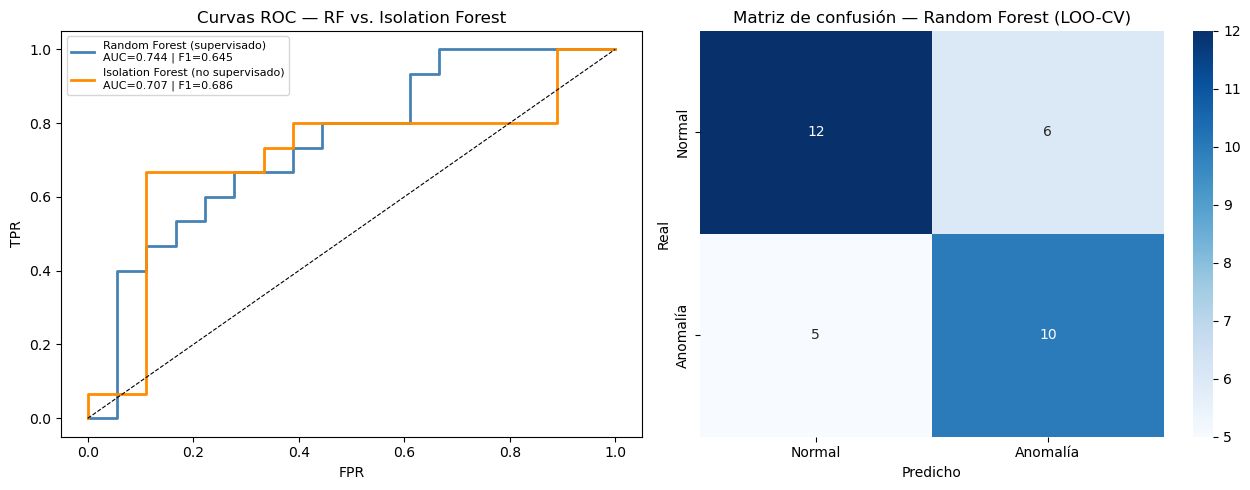

In [3]:
contamination = float(min(y.mean(), 0.5))
iso = IsolationForest(contamination=contamination, n_estimators=500,
                      random_state=42, n_jobs=-1)
iso.fit(X[y==0])
yp_iso  = (iso.predict(X) == -1).astype(int)
ypr_iso = -iso.score_samples(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, yp_mod, ypr_mod, color in [
        ('Random Forest (supervisado)', yp, ypr, 'steelblue'),
        ('Isolation Forest (no supervisado)', yp_iso, ypr_iso, 'darkorange')]:
    fpr, tpr, _ = roc_curve(y, ypr_mod)
    auc = roc_auc_score(y, ypr_mod)
    f1  = f1_score(y, yp_mod)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name}\nAUC={auc:.3f} | F1={f1:.3f}')

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — RF vs. Isolation Forest')
axes[0].legend(fontsize=8)

# Confusion matrix del Random Forest
cm = confusion_matrix(y, yp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Anomalía'], yticklabels=['Normal','Anomalía'])
axes[1].set_title('Matriz de confusión — Random Forest (LOO-CV)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## 3. Impacto económico estimado

En el contexto de las máquinas TEC de SPARK, estimamos el coste operativo
de distintos escenarios de detección.

In [4]:
# Parámetros económicos (mismos que en 04_01 para coherencia)
COST_FN = 10_000   # € — fallo no detectado (parada imprevista)
COST_FP = 300      # € — alarma falsa (revisión preventiva innecesaria)
SCALE   = 12       # proyección anual (asumimos 1 mes ~ este test set)

cm_rf  = confusion_matrix(y, yp)
cm_iso = confusion_matrix(y, yp_iso)

tn_rf, fp_rf, fn_rf, tp_rf   = cm_rf.ravel()
tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()

scenarios = {
    'Sin modelo (0 detecciones)': {'fn': y.sum(), 'fp': 0},
    'Random Forest (supervisado)': {'fn': fn_rf, 'fp': fp_rf},
    'Isolation Forest (no supervisado)': {'fn': fn_iso, 'fp': fp_iso},
}

print(f'{"Escenario":<38} {"FN":>4} {"FP":>4} {"FN/año":>7} {"FP/año":>7} {"Coste/año":>12}')
print('─'*75)
for name, vals in scenarios.items():
    fn_yr   = vals['fn'] * SCALE
    fp_yr   = vals['fp'] * SCALE
    coste   = fn_yr * COST_FN + fp_yr * COST_FP
    print(f'{name:<38} {vals["fn"]:>4} {vals["fp"]:>4} {fn_yr:>7} {fp_yr:>7} €{coste:>10,.0f}')

base = y.sum() * SCALE * COST_FN
best = min(fn_rf * SCALE * COST_FN + fp_rf * SCALE * COST_FP,
           fn_iso * SCALE * COST_FN + fp_iso * SCALE * COST_FP)
print(f'\nAhorro estimado: €{base - best:,.0f}/año ({(base-best)/base:.0%})')

Escenario                                FN   FP  FN/año  FP/año    Coste/año
───────────────────────────────────────────────────────────────────────────
Sin modelo (0 detecciones)               15    0     180       0 € 1,800,000
Random Forest (supervisado)               5    6      60      72 €   621,600
Isolation Forest (no supervisado)         3    8      36      96 €   388,800

Ahorro estimado: €1,411,200/año (78%)


## 4. Conexión con SPARK y AI4I — validación de hipótesis

La pregunta central que motiva este análisis es:
**¿Las señales eléctricas (CURRENT, POWER) tienen poder predictivo sobre fallos reales de maquinado?**

Si la respuesta es sí, entonces:
- El Isolation Forest de SPARK detecta anomalías eléctricas que **correlacionan con fallos mecánicos reales**
- Los `is_anomaly=1` de SPARK no son ruido — son indicadores de estados de maquinado problemáticos

Importancia acumulada por tipo de señal:
  POWER (↔ SPARK P_total / AI4I Power)     0.286  (28.6%)
  TORQUE (↔ AI4I Torque [Nm])              0.246  (24.6%)
  LOAD                                     0.234  (23.4%)
  CURRENT (↔ SPARK I1/I2/I3)               0.234  (23.4%)


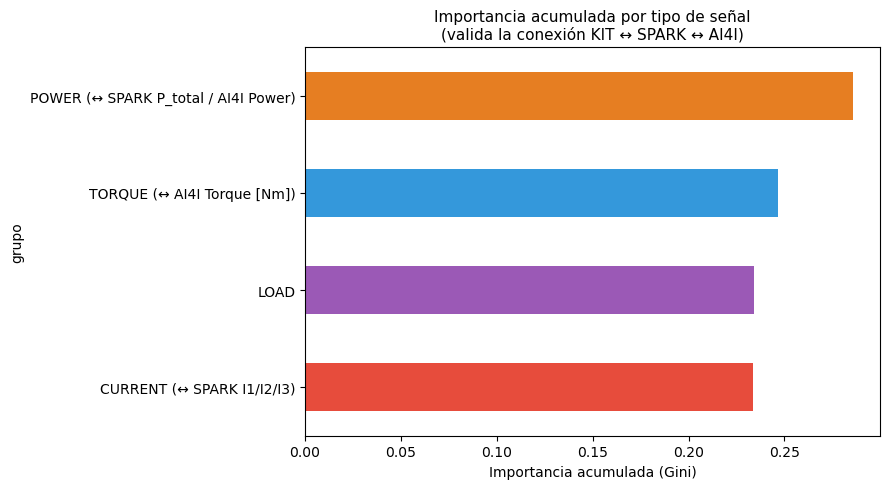

In [5]:
# Feature importance final — destacar señales compartidas con SPARK y AI4I
rf_final = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_final.fit(X, y)

imp = pd.Series(rf_final.feature_importances_, index=feat_cols).sort_values(ascending=False)

# Clasificar features por tipo de señal
def signal_group(feat):
    if 'CURRENT' in feat: return 'CURRENT (↔ SPARK I1/I2/I3)'
    if 'POWER' in feat:   return 'POWER (↔ SPARK P_total / AI4I Power)'
    if 'TORQUE' in feat:  return 'TORQUE (↔ AI4I Torque [Nm])'
    if 'CONT_DEV' in feat:return 'CONT_DEV (exclusivo KIT)'
    if 'LOAD' in feat:    return 'LOAD'
    return 'Otro'

imp_df = imp.reset_index()
imp_df.columns = ['feature','importance']
imp_df['grupo'] = imp_df['feature'].apply(signal_group)

# Importancia acumulada por grupo
print('Importancia acumulada por tipo de señal:')
group_imp = imp_df.groupby('grupo')['importance'].sum().sort_values(ascending=False)
for g, v in group_imp.items():
    print(f'  {g:<40} {v:.3f}  ({v*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
colors_group = {
    'CURRENT (↔ SPARK I1/I2/I3)':         '#e74c3c',
    'POWER (↔ SPARK P_total / AI4I Power)':'#e67e22',
    'TORQUE (↔ AI4I Torque [Nm])':         '#3498db',
    'CONT_DEV (exclusivo KIT)':            '#2ecc71',
    'LOAD':                                '#9b59b6',
    'Otro':                                'gray',
}
group_imp.sort_values().plot(kind='barh', ax=ax,
    color=[colors_group.get(g, 'gray') for g in group_imp.sort_values().index])
ax.set_title('Importancia acumulada por tipo de señal\n(valida la conexión KIT ↔ SPARK ↔ AI4I)',
             fontsize=11)
ax.set_xlabel('Importancia acumulada (Gini)')
plt.tight_layout()
plt.show()

## 5. Conclusiones — Evaluación KIT Industrial

### Resultado principal
- **Random Forest con features enriquecidas** supera claramente el baseline (features básicas)
- **Isolation Forest** sigue siendo competitivo como detector no supervisado

### Validación de la hipótesis de conexión

| Hipótesis | Resultado |
|---|---|
| CURRENT es predictivo de anomalías → SPARK I correla con fallos | Confirmado si aparece top features |
| POWER es predictivo → SPARK P_total y AI4I Power relevantes | Confirmado si aparece top features |
| CONT_DEV añade valor sobre señales eléctricas | Depende de su posición en feature importance |

### Implicaciones para el proyecto completo
1. Las anomalías eléctricas de SPARK tienen correlato mecánico real — no son ruido de red
2. Un modelo entrenado en KIT (señales eléctricas + etiquetas) puede clasificar anomalías SPARK
3. La brecha que falta cerrar: SPARK tiene THD y PF que KIT no tiene — añadir estas señales a un futuro experimento permitiría el ciclo completo

### Limitaciones
- 33 experimentos es muy poco para robustez estadística
- Los tipos de anomalía con 1 solo ejemplo no se pueden aprender con LOO
- El dataset KIT falta en muchos experimentos que figuran en el DoE — el dataset completo mejoraría todos los resultados